# CLIP Embedding Visualization

Projects the 512-dimensional CLIP image embeddings into 3D space using PCA and t-SNE,
then displays each point alongside its corresponding image.

**Left panel:** 3D scatter plot of projected embeddings
**Right panel:** Image thumbnails with labels

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from PIL import Image
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "multimodal").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

CACHE_DIR = PROJECT_ROOT / "multimodal" / "cache"
IMAGE_DIR = PROJECT_ROOT / "imagegen" / "images"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/sidharthbildikar/Desktop/code/ASR Project


## Load Embeddings and Images

In [2]:
embeddings_data = np.load(CACHE_DIR / "clip_image_embeddings.npz")

with open(CACHE_DIR / "clip_metadata.json") as f:
    meta = json.load(f)

image_files = meta["image_files"]
embeddings = np.array([embeddings_data[f] for f in image_files])

images = []
for f in image_files:
    img = Image.open(IMAGE_DIR / f).convert("RGB")
    images.append(img)

print(f"Loaded {len(embeddings)} embeddings, shape: {embeddings.shape}")
print(f"Loaded {len(images)} images")

Loaded 20 embeddings, shape: (20, 512)
Loaded 20 images


## PCA Projection to 3D

PCA finds the three orthogonal directions that capture the most variance in the
512-dimensional embedding space. This gives a linear, interpretable projection.

In [3]:
pca = PCA(n_components=3)
coords_pca = pca.fit_transform(embeddings)

explained = pca.explained_variance_ratio_
print(f"Variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, PC3={explained[2]:.1%}")
print(f"Total variance explained: {sum(explained):.1%}")

Variance explained: PC1=17.5%, PC2=9.9%, PC3=9.1%
Total variance explained: 36.4%


## PCA 3D Scatter with Image Thumbnails

Left: 3D scatter plot of the PCA-projected embeddings. Each point is one image.
Right: Grid of the actual images with their filenames.

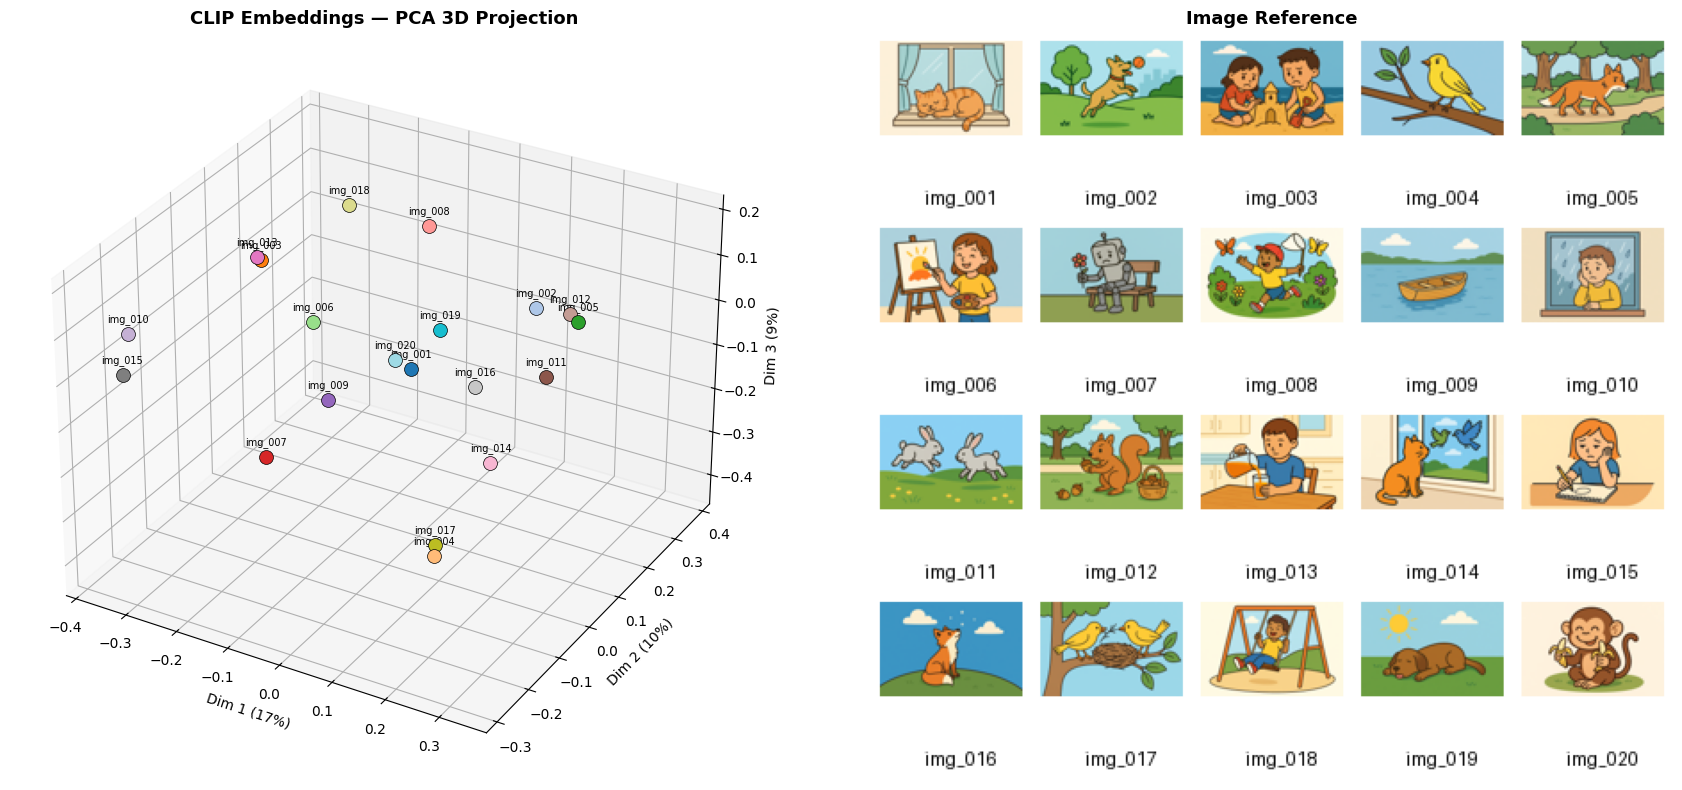

Saved: multimodal/cache/clip_pca_3d.png


In [4]:
def plot_3d_with_images(coords, images, image_files, title, explained=None):
    fig = plt.figure(figsize=(18, 8))

    # Left: 3D scatter
    ax3d = fig.add_subplot(121, projection="3d")

    colors = plt.cm.tab20(np.linspace(0, 1, len(coords)))
    for i, (x, y, z) in enumerate(coords):
        ax3d.scatter(x, y, z, c=[colors[i]], s=100, edgecolors="black", linewidth=0.5, zorder=5)
        ax3d.text(x, y, z + 0.02, image_files[i].replace(".png", ""),
                  fontsize=7, ha="center", va="bottom")

    xlabel = f"Dim 1 ({explained[0]:.0%})" if explained is not None else "Dim 1"
    ylabel = f"Dim 2 ({explained[1]:.0%})" if explained is not None else "Dim 2"
    zlabel = f"Dim 3 ({explained[2]:.0%})" if explained is not None else "Dim 3"
    ax3d.set_xlabel(xlabel, fontsize=10)
    ax3d.set_ylabel(ylabel, fontsize=10)
    ax3d.set_zlabel(zlabel, fontsize=10)
    ax3d.set_title(title, fontsize=13, fontweight="bold")

    # Right: image grid
    ax_grid = fig.add_subplot(122)
    ax_grid.axis("off")
    ax_grid.set_title("Image Reference", fontsize=13, fontweight="bold")

    cols = 5
    rows = (len(images) + cols - 1) // cols
    thumb_size = 80

    grid_img = Image.new("RGB", (cols * (thumb_size + 10), rows * (thumb_size + 25)), "white")
    from PIL import ImageDraw, ImageFont

    draw = ImageDraw.Draw(grid_img)
    for idx, (img, fname) in enumerate(zip(images, image_files)):
        r, c = divmod(idx, cols)
        x_off = c * (thumb_size + 10) + 5
        y_off = r * (thumb_size + 25) + 5
        thumb = img.copy()
        thumb.thumbnail((thumb_size, thumb_size))
        grid_img.paste(thumb, (x_off, y_off))
        label = fname.replace(".png", "")
        draw.text((x_off + thumb_size // 2 - 15, y_off + thumb_size + 2),
                  label, fill="black")

    ax_grid.imshow(grid_img)

    plt.tight_layout()
    return fig

fig_pca = plot_3d_with_images(coords_pca, images, image_files,
                               "CLIP Embeddings — PCA 3D Projection",
                               explained=explained)
plt.savefig("multimodal/cache/clip_pca_3d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multimodal/cache/clip_pca_3d.png")

## t-SNE Projection to 3D

t-SNE is a non-linear method that preserves local neighborhood structure.
Images that are semantically similar according to CLIP should cluster together.

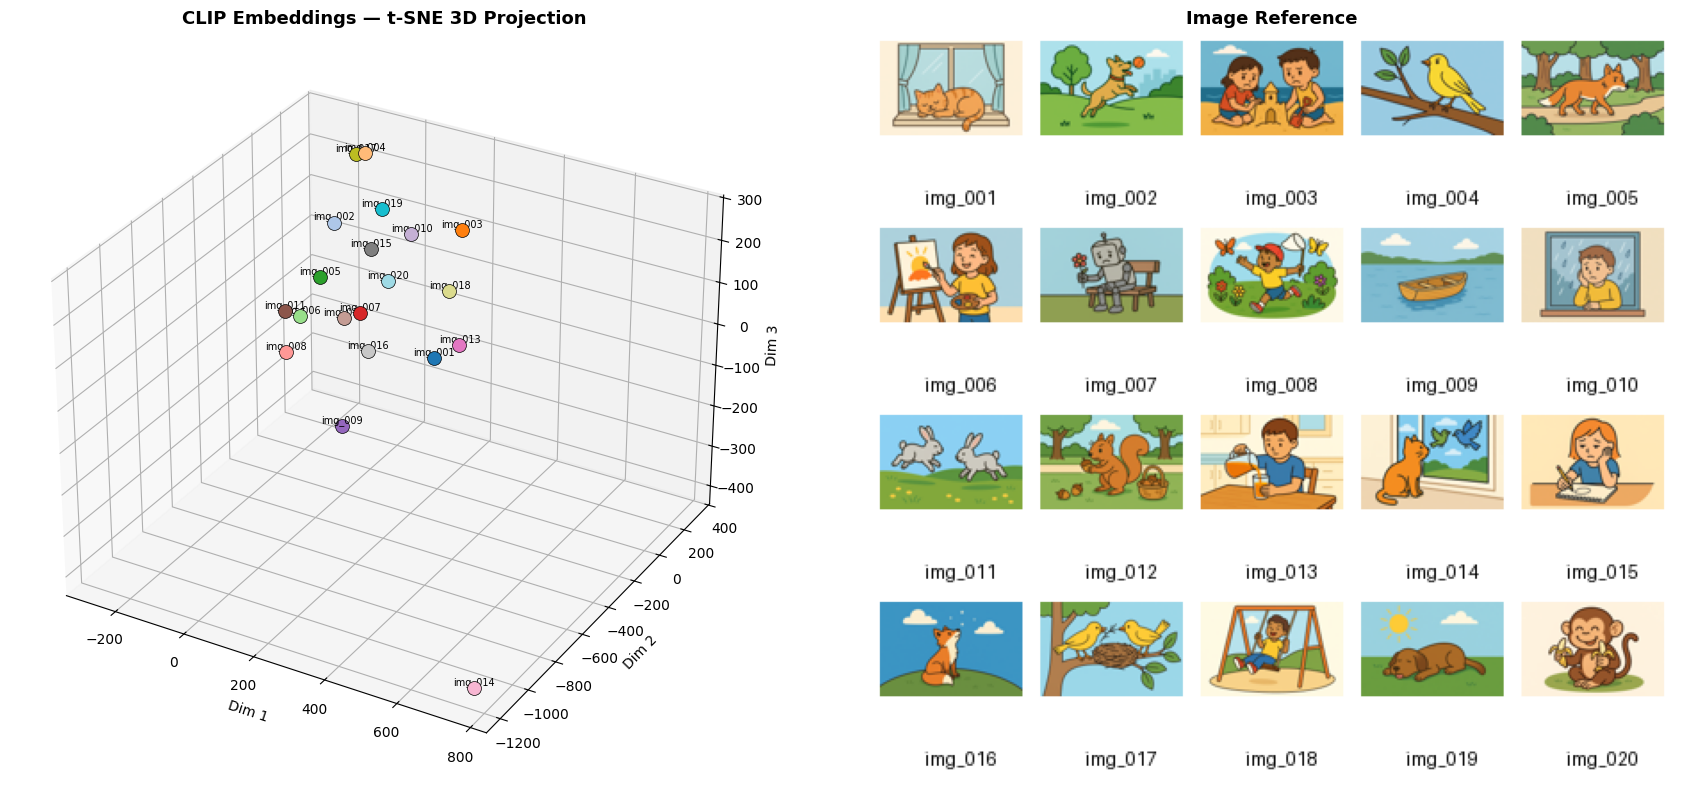

Saved: multimodal/cache/clip_tsne_3d.png


In [7]:
tsne = TSNE(n_components=3, perplexity=min(5, len(embeddings) - 1),
            random_state=42, max_iter=2000)
coords_tsne = tsne.fit_transform(embeddings)

fig_tsne = plot_3d_with_images(coords_tsne, images, image_files,
                                "CLIP Embeddings — t-SNE 3D Projection")
plt.savefig("multimodal/cache/clip_tsne_3d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multimodal/cache/clip_tsne_3d.png")

## Cosine Similarity Heatmap

Shows pairwise similarity between all image embeddings. Since CLIP embeddings are
L2-normalized, cosine similarity equals the dot product. High values (bright) mean
CLIP considers two images semantically similar.

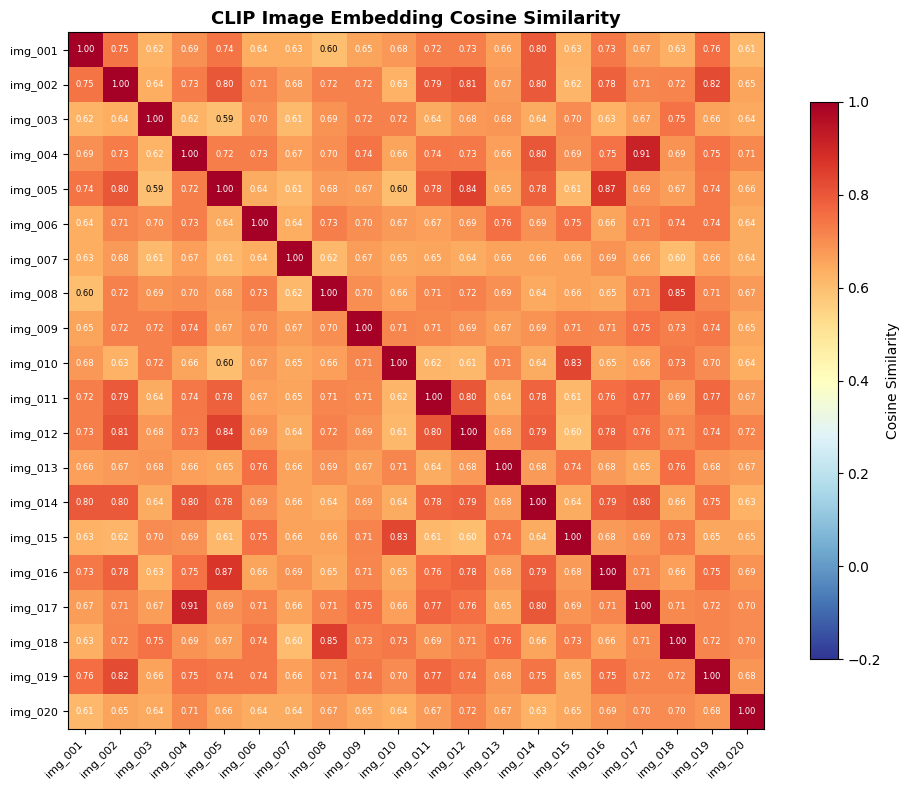

Saved: multimodal/cache/clip_similarity_heatmap.png


In [8]:
similarity = embeddings @ embeddings.T

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity, cmap="RdYlBu_r", vmin=-0.2, vmax=1.0)
ax.set_xticks(range(len(image_files)))
ax.set_yticks(range(len(image_files)))
labels = [f.replace(".png", "") for f in image_files]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("CLIP Image Embedding Cosine Similarity", fontsize=13, fontweight="bold")

for i in range(len(image_files)):
    for j in range(len(image_files)):
        val = similarity[i, j]
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Cosine Similarity")
plt.tight_layout()
plt.savefig("multimodal/cache/clip_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multimodal/cache/clip_similarity_heatmap.png")

## 2D Embedding Space with Image Overlays

Projects to 2D with PCA and overlays the actual image thumbnails on each point.
This is the most intuitive view of how CLIP organizes the images.

In [ ]:
pca_2d = PCA(n_components=2)
coords_2d = pca_2d.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0)

for i, (x, y) in enumerate(coords_2d):
    img = images[i].copy()
    img.thumbnail((64, 64))
    im = OffsetImage(np.array(img), zoom=0.8)
    ab = AnnotationBbox(im, (x, y), frameon=True,
                        bboxprops=dict(edgecolor="steelblue", linewidth=1.5))
    ax.add_artist(ab)
    ax.annotate(image_files[i].replace(".png", ""), (x, y),
                textcoords="offset points", xytext=(0, -35),
                fontsize=7, ha="center")

exp = pca_2d.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({exp[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({exp[1]:.1%} variance)", fontsize=11)
ax.set_title("CLIP Embedding Space — Images as Points", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("multimodal/cache/clip_2d_image_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multimodal/cache/clip_2d_image_overlay.png")

## Embedding Statistics

In [ ]:
print(f"Model: {meta['model']}")
print(f"Embedding dimension: {meta['embedding_dim']}")
print(f"Number of images: {meta['num_images']}")
print(f"Embedding norms (should be ~1.0 if L2-normalized):")
norms = np.linalg.norm(embeddings, axis=1)
print(f"  Mean: {norms.mean():.4f}, Std: {norms.std():.6f}")
print(f"  Min:  {norms.min():.4f}, Max: {norms.max():.4f}")

print(f"\nPairwise cosine similarity:")
triu = similarity[np.triu_indices(len(similarity), k=1)]
print(f"  Mean: {triu.mean():.4f}")
print(f"  Std:  {triu.std():.4f}")
print(f"  Min:  {triu.min():.4f} ({image_files[np.unravel_index(np.argmin(similarity + np.eye(len(similarity))*10), similarity.shape)[0]]} vs {image_files[np.unravel_index(np.argmin(similarity + np.eye(len(similarity))*10), similarity.shape)[1]]})")

most_similar = np.unravel_index(np.argmax(similarity - np.eye(len(similarity))*10), similarity.shape)
print(f"  Max:  {similarity[most_similar]:.4f} ({image_files[most_similar[0]]} vs {image_files[most_similar[1]]})")